**Cell 1: Import Libraries and Setup**

In [14]:
!pip install pvbm --quiet
!pip install opencv-python-headless --quiet
!pip install albumentations --quiet

import os
import cv2
import numpy as np
import zipfile
import shutil
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm import tqdm
import albumentations as A
from concurrent.futures import ThreadPoolExecutor
import warnings
warnings.filterwarnings('ignore')

from PVBM.DiscSegmenter import DiscSegmenter
from PIL import Image

# Initialize PVBM segmenter correctly
segmenter = DiscSegmenter()

# Set paths
INPUT_PATH = '/kaggle/input/datasets/victorlemosml/refuge2/REFUGE2'
OUTPUT_PATH = '/kaggle/working/preprocessed_refuge2_od_cropped'
os.makedirs(OUTPUT_PATH, exist_ok=True)

print(f"Input path exists: {os.path.exists(INPUT_PATH)}")
print(f"Output path created: {OUTPUT_PATH}")
print("PVBM DiscSegmenter initialized successfully!")

^C
ERROR: Operation cancelled by user
^C
ERROR: Operation cancelled by user
^C
ERROR: Operation cancelled by user
Model path: /usr/local/lib/python3.12/dist-packages/PVBM/lunetv2_odc.onnx
Model already exists, skipping download.
Input path exists: True
Output path created: /kaggle/working/preprocessed_refuge2_od_cropped
PVBM DiscSegmenter initialized successfully!


**Cell 2: Define Optic Disc Cropping Functions**

In [15]:
def get_optic_disc(image_path):
    """Get optic disc mask and center coordinates using PVBM"""
    try:
        optic_disc_pil = segmenter.segment(image_path=image_path)
        optic_disc = np.array(optic_disc_pil)
        center, radius, roi, zones_ABC = segmenter.post_processing(
            segmentation=optic_disc_pil,
            max_roi_size=600
        )
        return optic_disc, center, radius
    except Exception as e:
        print(f"PVBM Error: {e}")
        return None, None, None

def getDiscFromOriginalImage(img_cropped, optic_disc_mask):
    """Extract optic disc region from cropped image using mask"""
    masked = cv2.bitwise_and(img_cropped, img_cropped, mask=optic_disc_mask)
    masked = cv2.resize(masked, (256, 256))
    mb, mg, mr = cv2.split(masked)
    masked = cv2.merge((mb, mg, mr))
    return masked

def countingBox(optic_disc, img):
    """Crop image around optic disc based on mask"""
    try:
        optic_disc = np.array(optic_disc)
        
        if len(optic_disc.shape) == 3:
            optic_disc = cv2.cvtColor(optic_disc, cv2.COLOR_RGB2GRAY)
        
        _, binary_mask = cv2.threshold(optic_disc, 1, 255, cv2.THRESH_BINARY)
        
        ys, xs = np.where(binary_mask > 0)
        
        # Check if mask has any white pixels
        if len(ys) == 0 or len(xs) == 0:
            return None, None
        
        # Add padding of 50 pixels with bounds checking
        h, w = binary_mask.shape
        ymin = max(ys.min() - 50, 0)
        ymax = min(ys.max() + 50, h - 1)
        xmin = max(xs.min() - 50, 0)
        xmax = min(xs.max() + 50, w - 1)
        
        # Check if crop region is valid
        if ymin >= ymax or xmin >= xmax:
            return None, None
        
        resized_img = cv2.resize(img, (binary_mask.shape[1], binary_mask.shape[0]))
        img_cropped = resized_img[ymin:ymax+1, xmin:xmax+1]
        optic_disc_mask = optic_disc[ymin:ymax+1, xmin:xmax+1]
        
        if img_cropped.size == 0 or optic_disc_mask.size == 0:
            return None, None
        
        return img_cropped, optic_disc_mask
    except Exception as e:
        print(f"CountingBox Error: {e}")
        return None, None

def crop_image_from_gray(img, tol=7):
    """Remove black borders around the optic disc"""
    if img is None or img.size == 0:
        return np.zeros((256, 256, 3), dtype=np.uint8)
    
    if img.ndim == 2:
        mask = img > tol
        if mask.any():
            return img[np.ix_(mask.any(1), mask.any(0))]
        return img
    elif img.ndim == 3:
        gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        mask = gray_img > tol
        
        if img[:, :, 0][np.ix_(mask.any(1), mask.any(0))].shape[0] == 0:
            return img
        else:
            img1 = img[:, :, 0][np.ix_(mask.any(1), mask.any(0))]
            img2 = img[:, :, 1][np.ix_(mask.any(1), mask.any(0))]
            img3 = img[:, :, 2][np.ix_(mask.any(1), mask.any(0))]
            img = np.stack([img1, img2, img3], axis=-1)
        return img

def crop_optic_disc_from_path(image_path):
    """Complete pipeline: load image, detect disc, crop, return cropped disc"""
    try:
        img = cv2.imread(image_path)
        if img is None:
            return None
        
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        od_mask, center, radius = get_optic_disc(image_path)
        
        if od_mask is None:
            return None
        
        img_cropped, optic_disc_mask = countingBox(od_mask, img)
        
        if img_cropped is None or optic_disc_mask is None:
            return None
        
        od_masked = getDiscFromOriginalImage(img_cropped, optic_disc_mask)
        od_cropped = crop_image_from_gray(od_masked)
        
        return od_cropped
    
    except Exception as e:
        print(f"Error in crop_optic_disc_from_path: {e}")
        return None

**Cell 3: Define Mask Processing for Cropped Optic Disc**

In [16]:
def process_mask_for_cropped_od(mask_path, od_center, od_radius, original_img_shape, crop_coords):
    """
    Process mask to align with cropped optic disc region
    """
    try:
        # Read original mask
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            return None
        
        # Resize mask to match original image dimensions if needed
        if mask.shape != original_img_shape[:2]:
            mask = cv2.resize(mask, (original_img_shape[1], original_img_shape[0]), 
                            interpolation=cv2.INTER_NEAREST)
        
        # Crop mask to the same region as the optic disc
        if crop_coords:
            ymin, ymax, xmin, xmax = crop_coords
            cropped_mask = mask[ymin:ymax+1, xmin:xmax+1]
            
            # Resize to 256x256
            cropped_mask = cv2.resize(cropped_mask, (256, 256), 
                                    interpolation=cv2.INTER_NEAREST)
            
            # Threshold to binary
            cropped_mask = (cropped_mask > 127).astype(np.float32)
            
            return cropped_mask
        
        return None
    
    except Exception as e:
        print(f"Error processing mask: {e}")
        return None

def get_crop_coordinates(optic_disc, img_shape):
    """Extract crop coordinates from the countingBox operation"""
    try:
        if len(optic_disc.shape) == 3:
            optic_disc_gray = cv2.cvtColor(optic_disc, cv2.COLOR_RGB2GRAY)
        else:
            optic_disc_gray = optic_disc
        
        _, binary_mask = cv2.threshold(optic_disc_gray, 1, 255, cv2.THRESH_BINARY)
        ys, xs = np.where(binary_mask > 0)
        
        if len(ys) == 0 or len(xs) == 0:
            return None
        
        ymin = max(ys.min() - 50, 0)
        ymax = min(ys.max() + 50, binary_mask.shape[0] - 1)
        xmin = max(xs.min() - 50, 0)
        xmax = min(xs.max() + 50, binary_mask.shape[1] - 1)
        
        return (ymin, ymax, xmin, xmax)
    
    except Exception:
        return None

**Cell 4: Main Processing Pipeline**

In [17]:
def process_dataset_split_with_od_crop(input_base_path, output_base_path, split_name):
    """
    Process a dataset split with optic disc cropping
    """
    results = {'images': 0, 'masks': 0, 'failed': 0, 'errors': []}
    
    # Define input paths
    input_images = os.path.join(input_base_path, split_name, 'images')
    input_masks = os.path.join(input_base_path, split_name, 'mask')
    
    # Define output paths
    output_images = os.path.join(output_base_path, split_name, 'images')
    output_masks = os.path.join(output_base_path, split_name, 'mask')
    
    # Check if directories exist
    if not os.path.exists(input_images):
        print(f"Warning: {input_images} does not exist")
        return results
    
    # Create output directories
    os.makedirs(output_images, exist_ok=True)
    os.makedirs(output_masks, exist_ok=True)
    
    print(f"\nProcessing {split_name} split...")
    
    # Get all image files
    image_files = [f for f in os.listdir(input_images) 
                   if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tiff', '.bmp'))]
    
    print(f"Found {len(image_files)} images to process")
    
    # Process images
    for img_file in tqdm(image_files, desc=f"Processing {split_name}"):
        try:
            img_path = os.path.join(input_images, img_file)
            img_name = Path(img_file).stem
            
            # Apply optic disc cropping
            od_cropped = crop_optic_disc_from_path(img_path)
            
            if od_cropped is None:
                results['failed'] += 1
                results['errors'].append(f"Failed to crop OD from {img_name}")
                continue
            
            # Ensure size is 256x256
            if od_cropped.shape[:2] != (256, 256):
                od_cropped = cv2.resize(od_cropped, (256, 256))
            
            # Normalize and enhance cropped image
            od_cropped = od_cropped.astype(np.float32) / 255.0
            
            # Apply CLAHE on cropped region
            lab = cv2.cvtColor((od_cropped * 255).astype(np.uint8), cv2.COLOR_RGB2LAB)
            l, a, b = cv2.split(lab)
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
            l = clahe.apply(l)
            lab = cv2.merge([l, a, b])
            od_cropped = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB) / 255.0
            
            # Save processed optic disc image
            output_img_path = os.path.join(output_images, f"{img_name}.npy")
            np.save(output_img_path, od_cropped)
            
            # Process corresponding mask
            if os.path.exists(input_masks):
                # Find mask file
                mask_file = None
                for ext in ['.png', '.jpg', '.jpeg', '.bmp']:
                    potential_mask = os.path.join(input_masks, f"{img_name}{ext}")
                    if os.path.exists(potential_mask):
                        mask_file = potential_mask
                        break
                
                if mask_file:
                    # For cropped OD, we need to create a corresponding binary mask
                    # Since we cropped to the OD region, the mask should indicate OD presence
                    mask = cv2.imread(mask_file, cv2.IMREAD_GRAYSCALE)
                    
                    # Resize to 256x256 and threshold
                    mask_resized = cv2.resize(mask, (256, 256), interpolation=cv2.INTER_NEAREST)
                    binary_mask = (mask_resized > 127).astype(np.float32)
                    
                    # Save mask
                    output_mask_path = os.path.join(output_masks, f"{img_name}.npy")
                    np.save(output_mask_path, binary_mask)
                    results['masks'] += 1
                else:
                    # Create a default mask based on the cropped OD region
                    # Since we cropped to OD, create a mask with a circle in the center
                    h, w = od_cropped.shape[:2]
                    center = (w//2, h//2)
                    radius = min(w, h) // 3
                    Y, X = np.ogrid[:h, :w]
                    dist_from_center = np.sqrt((X - center[0])**2 + (Y - center[1])**2)
                    default_mask = (dist_from_center <= radius).astype(np.float32)
                    
                    output_mask_path = os.path.join(output_masks, f"{img_name}.npy")
                    np.save(output_mask_path, default_mask)
                    results['masks'] += 1
                    results['errors'].append(f"Created default mask for {img_name}")
            
            results['images'] += 1
            
        except Exception as e:
            results['failed'] += 1
            results['errors'].append(f"Error processing {img_file}: {str(e)}")
    
    return results

**Cell 5: Test on Single Image**

In [18]:
test_image = '/kaggle/input/datasets/victorlemosml/refuge2/REFUGE2/train/images/g0001.jpg'  
result = crop_optic_disc_from_path(test_image)

# Save and display the output
if result is not None:
    # Save the image
    output_path = '/kaggle/working/cropped_optic_disc.jpg'
    result_uint8 = (result * 255).astype(np.uint8)
    cv2.imwrite(output_path, cv2.cvtColor(result_uint8, cv2.COLOR_RGB2BGR))
    
    # Display the image
    plt.figure(figsize=(4, 5))
    plt.imshow(result)
    plt.title(f'Cropped Optic Disc', fontsize=10)
    plt.axis('off')
    plt.show()
    
    print(f"✅ Image saved to: {output_path}")
    print(f"📊 Image shape: {result.shape}")
    print(f"📊 Value range: [{result.min():.3f}, {result.max():.3f}]")
else:
    print("❌ Failed to process the image")

KeyboardInterrupt: 

In [ ]:
plt.imshow(cv2.imread(test_image))

**Cell 6: Optic Mask**

In [ ]:
cropped_od_path = '/kaggle/input/datasets/victorlemosml/refuge2/REFUGE2/test/mask/T0005.bmp'

# Load the cropped optic disc
cropped_od = cv2.imread(cropped_od_path)
cropped_od = cv2.cvtColor(cropped_od, cv2.COLOR_BGR2RGB)

# Calculate center of the cropped optic disc
h, w = cropped_od.shape[:2]
center_x, center_y = w // 2, h // 2
radius = min(h, w) // 2

# Create optic cup mask (half the disc radius)
cup_radius = radius // 2

# Create blank mask and draw circle for optic cup
cup_binary = np.zeros((h, w), dtype=np.uint8)
cv2.circle(cup_binary, (center_x, center_y), cup_radius, 255, -1)

# Display both
fig, axes = plt.subplots(1, 2, figsize=(6, 5))

# Cropped optic disc
axes[0].imshow(cropped_od)
axes[0].set_title(f'Cropped Optic Disc', fontsize=10)
axes[0].axis('off')

# Binary optic cup mask
axes[1].imshow(cup_binary, cmap='gray')
axes[1].set_title(f'Optic Cup Mask', fontsize=10)
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f"\n✅ Cropped Optic Disc shape: {cropped_od.shape}")
print(f"✅ Binary Optic Cup Mask shape: {cup_binary.shape}")
print(f"📊 Cup radius: {cup_radius} pixels")
print(f"📊 Cup area: {np.sum(cup_binary > 0)} pixels")

**Cell 7: Overlay on 1 image**

In [ ]:
test_image = '/kaggle/input/datasets/victorlemosml/refuge2/REFUGE2/train/images/g0002.jpg'  
result = crop_optic_disc_from_path(test_image)

# Save and display the output
if result is not None:
    # Save the image - REMOVE RGB to BGR conversion
    output_path = '/kaggle/working/cropped_optic_disc.jpg'
    result_uint8 = (result * 255).astype(np.uint8)
    cv2.imwrite(output_path, result_uint8)  # Direct save, no color conversion
    
    # Create optic cup mask
    h, w = result_uint8.shape[:2]
    center_x, center_y = w // 2, h // 2
    radius = min(h, w) // 2
    cup_radius = radius // 2
    
    cup_binary = np.zeros((h, w), dtype=np.uint8)
    cv2.circle(cup_binary, (center_x, center_y), cup_radius, 255, -1)
    
    # Create overlay 
    overlay = result_uint8.copy()
    # Draw only outline instead of filling
    contours, _ = cv2.findContours(cup_binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(overlay, contours, -1, (0, 255, 0), 2)  # Green outline, thickness 2
    
    # Display all three
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    
    # Cropped optic disc
    axes[0].imshow(result_uint8)
    axes[0].set_title(f'Cropped Optic Disc', fontsize=10)
    axes[0].axis('off')
    
    # Optic cup mask
    axes[1].imshow(cup_binary, cmap='gray')
    axes[1].set_title(f'Optic Cup Mask', fontsize=10)
    axes[1].axis('off')
    
    # Overlay (green outline)
    axes[2].imshow(overlay)
    axes[2].set_title(f'Overlay (Cup Outline in Green)', fontsize=10)
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"✅ Cropped Optic Disc shape: {result_uint8.shape}")
    print(f"✅ Optic Cup Mask shape: {cup_binary.shape}")
    print(f"📊 Cup radius: {cup_radius} pixels")
    print(f"📊 Cup area: {np.sum(cup_binary > 0)} pixels")
else:
    print("❌ Failed to process the image")

**Cell 8: Process all images and create single ZIP**

In [ ]:
# BATCH PROCESSING - Extract optic cup only for all REFUGE2 images
import zipfile
from tqdm import tqdm
import shutil

# Set paths for REFUGE2
INPUT_PATH = '/kaggle/input/datasets/victorlemosml/refuge2/REFUGE2'
OUTPUT_PATH = '/kaggle/working/REFUGE2_Cropped'

# Clean previous output
if os.path.exists(OUTPUT_PATH):
    shutil.rmtree(OUTPUT_PATH)
os.makedirs(OUTPUT_PATH)

# Define splits
splits = ['train', 'val', 'test']
stats = {}

print("="*60)
print("PROCESSING REFUGE2 - EXTRACTING OPTIC CUP ONLY")
print("="*60)

for split in splits:
    input_images_dir = os.path.join(INPUT_PATH, split, 'images')
    input_masks_dir = os.path.join(INPUT_PATH, split, 'mask')
    
    if not os.path.exists(input_images_dir):
        print(f"⚠ Skipping {split} - directory not found")
        continue
    
    # Create output directories
    output_images_dir = os.path.join(OUTPUT_PATH, split, 'images')
    output_masks_dir = os.path.join(OUTPUT_PATH, split, 'mask')
    os.makedirs(output_images_dir, exist_ok=True)
    os.makedirs(output_masks_dir, exist_ok=True)
    
    # Get all images
    image_files = [f for f in os.listdir(input_images_dir) 
                   if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff'))]
    
    print(f"\n📁 Processing {split.upper()} - {len(image_files)} images")
    
    success_count = 0
    for img_file in tqdm(image_files, desc=f"  {split}"):
        try:
            img_path = os.path.join(input_images_dir, img_file)
            img_name = Path(img_file).stem
            
            # Get cropped optic disc
            cropped_od = crop_optic_disc_from_path(img_path)
            
            if cropped_od is None:
                continue
            
            # Resize to 256x256
            cropped_od_resized = cv2.resize(cropped_od, (256, 256))
            
            # Convert RGB to BGR and save cropped optic disc
            cropped_od_bgr = cv2.cvtColor(cropped_od_resized, cv2.COLOR_RGB2BGR)
            output_img_path = os.path.join(output_images_dir, f"{img_name}.jpg")
            cv2.imwrite(output_img_path, cropped_od_bgr)
            
            # Find corresponding ground truth mask
            mask_file = None
            for ext in ['.png', '.jpg', '.jpeg', '.bmp']:
                potential_mask = os.path.join(input_masks_dir, f"{img_name}{ext}")
                if os.path.exists(potential_mask):
                    mask_file = potential_mask
                    break
            
            if mask_file:
                # Load original ground truth mask
                original_mask = cv2.imread(mask_file, cv2.IMREAD_GRAYSCALE)
                
                # Resize to 256x256
                original_mask_resized = cv2.resize(original_mask, (256, 256))
                
                # EXTRACT ONLY THE OPTIC CUP (value 255)
                # This gives exactly the middle white region you want
                optic_cup_only = (original_mask_resized == 255).astype(np.uint8) * 255
            else:
                optic_cup_only = np.zeros((256, 256), dtype=np.uint8)
            
            # Save the optic cup mask
            output_mask_path = os.path.join(output_masks_dir, f"{img_name}.png")
            cv2.imwrite(output_mask_path, optic_cup_only)
            
            success_count += 1
            
        except Exception as e:
            continue
    
    stats[split] = success_count
    print(f"  ✅ {split}: {success_count} images processed")

# Create single ZIP file
print("\n" + "="*60)
print("CREATING SINGLE ZIP FILE")
print("="*60)

zip_output_path = '/kaggle/working/REFUGE2_Optic_Cup_Only.zip'

with zipfile.ZipFile(zip_output_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(OUTPUT_PATH):
        for file in files:
            file_path = os.path.join(root, file)
            arcname = os.path.relpath(file_path, os.path.dirname(OUTPUT_PATH))
            zipf.write(file_path, arcname)

zip_size_mb = os.path.getsize(zip_output_path) / (1024**2)
print(f"\n✅ ZIP created: {zip_output_path}")
print(f"📊 Size: {zip_size_mb:.2f} MB")

print("\n📁 Output ZIP Structure:")
print("  REFUGE2_Cropped/")
print("    ├── train/")
print("    │   ├── images/ (cropped optic discs)")
print("    │   └── mask/ (optic cup only - white cup on black)")
print("    ├── val/")
print("    │   ├── images/")
print("    │   └── mask/")
print("    └── test/")
print("        ├── images/")
print("        └── mask/")

from IPython.display import FileLink, display
display(FileLink(zip_output_path))

In [19]:
!pip install pvbm --quiet
!pip install opencv-python-headless --quiet

import os
import cv2
import numpy as np
import zipfile
import shutil
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

from PVBM.DiscSegmenter import DiscSegmenter
from PIL import Image

# Initialize PVBM segmenter
segmenter = DiscSegmenter()

# Set paths
INPUT_PATH = '/kaggle/input/datasets/victorlemosml/refuge2/REFUGE2'
OUTPUT_PATH = '/kaggle/working/REFUGE2_Cropped'

print("PVBM Initialized Successfully!")

Model path: /usr/local/lib/python3.12/dist-packages/PVBM/lunetv2_odc.onnx
Model already exists, skipping download.
PVBM Initialized Successfully!


In [20]:
'''
Getting optic disc crop out region or ROI from original full CFI
'''

def get_optic_disc(image_path):
    """Get optic disc mask and center coordinates using PVBM"""
    try:
        optic_disc_pil = segmenter.segment(image_path=image_path)
        optic_disc = np.array(optic_disc_pil)
        center, radius, roi, zones_ABC = segmenter.post_processing(
            segmentation=optic_disc_pil,
            max_roi_size=600
        )
        return optic_disc, center, radius
    except Exception as e:
        return None, None, None

def getDiscFromOriginalImage(img_cropped, optic_disc_mask):
    masked = cv2.bitwise_and(img_cropped, img_cropped, mask=optic_disc_mask)
    masked = cv2.resize(masked, (256, 256))
    mb, mg, mr = cv2.split(masked)
    masked = cv2.merge((mb, mg, mr))
    return masked

def countingBox(optic_disc, img):
    """Crop image around optic disc based on mask"""
    try:
        optic_disc = np.array(optic_disc)

        if len(optic_disc.shape) == 3:
            optic_disc = cv2.cvtColor(optic_disc, cv2.COLOR_RGB2GRAY)

        _, binary_mask = cv2.threshold(optic_disc, 1, 255, cv2.THRESH_BINARY)

        ys, xs = np.where(binary_mask > 0)
        
        # Check if mask has any white pixels
        if len(ys) == 0 or len(xs) == 0:
            return None, None
        
        # Add padding of 50 pixels with bounds checking
        h, w = binary_mask.shape
        ymin = max(ys.min() - 50, 0)
        ymax = min(ys.max() + 50, h - 1)
        xmin = max(xs.min() - 50, 0)
        xmax = min(xs.max() + 50, w - 1)
        
        # Check if crop region is valid
        if ymin >= ymax or xmin >= xmax:
            return None, None

        resized_img = cv2.resize(img, (binary_mask.shape[1], binary_mask.shape[0]))

        img_cropped = resized_img[ymin:ymax+1, xmin:xmax+1]
        optic_disc_mask = optic_disc[ymin:ymax+1, xmin:xmax+1]
        
        if img_cropped.size == 0 or optic_disc_mask.size == 0:
            return None, None

        return img_cropped, optic_disc_mask
    except Exception as e:
        return None, None

def crop_image_from_gray(img, tol=7):
    if img is None or img.size == 0:
        return np.zeros((256, 256, 3), dtype=np.uint8)
    
    if img.ndim == 2:
        mask = img > tol
        if mask.any():
            return img[np.ix_(mask.any(1), mask.any(0))]
        return img
    elif img.ndim == 3:
        gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        mask = gray_img > tol

        if img[:, :, 0][np.ix_(mask.any(1), mask.any(0))].shape[0] == 0:
            return img
        else:
            img1 = img[:, :, 0][np.ix_(mask.any(1), mask.any(0))]
            img2 = img[:, :, 1][np.ix_(mask.any(1), mask.any(0))]
            img3 = img[:, :, 2][np.ix_(mask.any(1), mask.any(0))]
            img = np.stack([img1, img2, img3], axis=-1)
        return img

def crop_image_from_gray_with_coords(img, tol=7):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    mask = gray > tol

    if not mask.any():
        h,w = img.shape[:2]
        return img, (0,h,0,w)

    rows = mask.any(1)
    cols = mask.any(0)

    ymin = np.where(rows)[0][0]
    ymax = np.where(rows)[0][-1]

    xmin = np.where(cols)[0][0]
    xmax = np.where(cols)[0][-1]

    cropped = img[
        ymin:ymax+1,
        xmin:xmax+1
    ]

    return cropped, (ymin,ymax,xmin,xmax)

def crop_mask_using_pvbm(mask_path, center, radius):
    mask = cv2.imread(mask_path)
    h, w = mask.shape[:2]
    cx, cy = int(center[0]), int(center[1])
    r = int(radius * 1.2)
    r = min(r, 600//2)
    xmin = max(cx-r, 0)
    xmax = min(cx+r, w)
    ymin = max(cy-r, 0)
    ymax = min(cy+r, h)

    cropped_mask = mask[ymin:ymax, xmin:xmax]
    cropped_mask = cv2.resize(cropped_mask,(256,256),interpolation=cv2.INTER_NEAREST)
    gray = cv2.cvtColor(cropped_mask,cv2.COLOR_BGR2GRAY)
    oc_mask = cv2.inRange(gray,0,20)

    return oc_mask    

def crop_optic_disc_from_path(image_path):
    """Complete pipeline: load image, detect disc, crop, return cropped disc"""
    try:
        img = cv2.imread(image_path)
        od_mask, center, radius = get_optic_disc(image_path)
        img_cropped, optic_disc_mask = countingBox(od_mask, img)
        od_mask = getDiscFromOriginalImage(img_cropped, optic_disc_mask)
        od_mask = crop_image_from_gray(od_mask)
        
        return od_mask
    
    except Exception as e:
        return e

def crop_optic_disc_and_mask(image_path, mask_path):
    img = cv2.imread(image_path)
    od_mask, center, radius = get_optic_disc(image_path)
    mask = crop_mask_using_pvbm(mask_path, center, radius)
    img_cropped, optic_disc_mask = countingBox(od_mask,img)
    cropped_image = getDiscFromOriginalImage(img_cropped,optic_disc_mask)
    cropped_image, (ymin,ymax,xmin,xmax) = crop_image_from_gray_with_coords(cropped_image)
    cropped_mask = mask[
        ymin:ymax+1,
        xmin:xmax+1
    ]

    return cropped_image, cropped_mask

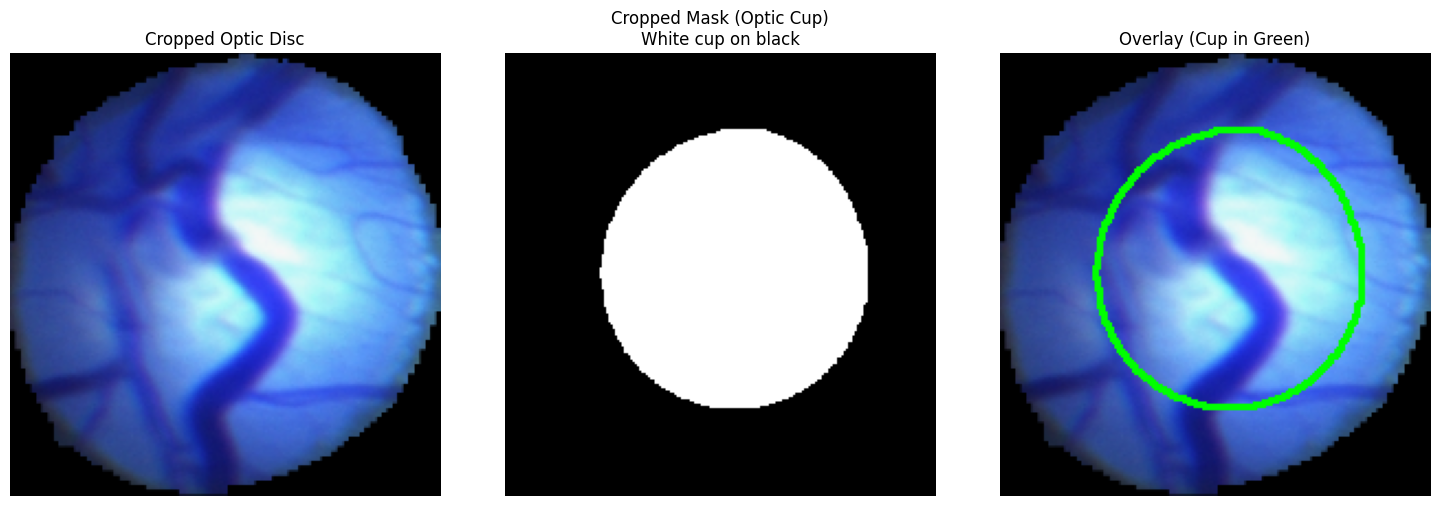

Cropped Image shape: (202, 196, 3)
Cropped Mask shape: (202, 196)
Mask unique values: [  0 255]
Cup area: 12152 pixels
✅ Saved: test_cropped_od.jpg (BGR format for correct colors)


In [21]:
# Test on single image
test_image = '/kaggle/input/datasets/victorlemosml/refuge2/REFUGE2/train/images/g0001.jpg'
test_mask = '/kaggle/input/datasets/victorlemosml/refuge2/REFUGE2/train/mask/g0001.bmp'

# Use sir's function
cropped_image, cropped_mask = crop_optic_disc_and_mask(test_image, test_mask)

# Convert RGB to BGR for saving (to preserve colors)
cropped_image_bgr = cv2.cvtColor(cropped_image, cv2.COLOR_RGB2BGR)

# Display results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Cropped optic disc (RGB for display)
axes[0].imshow(cropped_image)
axes[0].set_title('Cropped Optic Disc')
axes[0].axis('off')

# Cropped mask (optic cup)
axes[1].imshow(cropped_mask, cmap='gray')
axes[1].set_title('Cropped Mask (Optic Cup)\nWhite cup on black')
axes[1].axis('off')

# Overlay
overlay = cropped_image.copy()
contours, _ = cv2.findContours(cropped_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cv2.drawContours(overlay, contours, -1, (0, 255, 0), 2)
axes[2].imshow(overlay)
axes[2].set_title('Overlay (Cup in Green)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

# Save with BGR conversion
cv2.imwrite('/kaggle/working/test_cropped_od.jpg', cropped_image_bgr)
cv2.imwrite('/kaggle/working/test_cropped_mask.png', cropped_mask)

print(f"Cropped Image shape: {cropped_image.shape}")
print(f"Cropped Mask shape: {cropped_mask.shape}")
print(f"Mask unique values: {np.unique(cropped_mask)}")
print(f"Cup area: {np.sum(cropped_mask > 0)} pixels")
print(f"✅ Saved: test_cropped_od.jpg (BGR format for correct colors)")

In [23]:
# Batch process all images
INPUT_PATH = '/kaggle/input/datasets/victorlemosml/refuge2/REFUGE2'
OUTPUT_PATH = '/kaggle/working/REFUGE2_Cropped'

if os.path.exists(OUTPUT_PATH):
    shutil.rmtree(OUTPUT_PATH)
os.makedirs(OUTPUT_PATH)

splits = ['train', 'val', 'test']
stats = {}

print("="*60)
print("PROCESSING ALL IMAGES - Using Sir's Function")
print("="*60)

for split in splits:
    images_dir = os.path.join(INPUT_PATH, split, 'images')
    masks_dir = os.path.join(INPUT_PATH, split, 'mask')
    
    if not os.path.exists(images_dir):
        print(f"⚠ Skipping {split}")
        continue
    
    out_images_dir = os.path.join(OUTPUT_PATH, split, 'images')
    out_masks_dir = os.path.join(OUTPUT_PATH, split, 'mask')
    os.makedirs(out_images_dir, exist_ok=True)
    os.makedirs(out_masks_dir, exist_ok=True)
    
    image_files = [f for f in os.listdir(images_dir) 
                   if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]
    
    print(f"\n📁 {split} - {len(image_files)} images")
    
    success = 0
    for img_file in tqdm(image_files):
        try:
            img_name = Path(img_file).stem
            img_path = os.path.join(images_dir, img_file)
            
            # Find corresponding mask
            mask_file = None
            for ext in ['.bmp', '.png', '.jpg']:
                potential = os.path.join(masks_dir, f"{img_name}{ext}")
                if os.path.exists(potential):
                    mask_file = potential
                    break
            
            if mask_file is None:
                continue
            
            # Use sir's function
            cropped_image, cropped_mask = crop_optic_disc_and_mask(img_path, mask_file)
            
            # Convert RGB to BGR for saving (to preserve original colors)
            cropped_image_bgr = cv2.cvtColor(cropped_image, cv2.COLOR_RGB2BGR)
            
            # Save cropped optic disc
            output_img_path = os.path.join(out_images_dir, f"{img_name}.jpg")
            cv2.imwrite(output_img_path, cropped_image_bgr)
            
            # Save cropped mask
            output_mask_path = os.path.join(out_masks_dir, f"{img_name}.png")
            cv2.imwrite(output_mask_path, cropped_mask)
            
            success += 1
            
        except Exception as e:
            continue
    
    stats[split] = success
    print(f"  ✅ {split}: {success} images")

# Create ZIP
zip_path = '/kaggle/working/REFUGE2_Processed.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(OUTPUT_PATH):
        for file in files:
            zipf.write(os.path.join(root, file), os.path.relpath(os.path.join(root, file), os.path.dirname(OUTPUT_PATH)))

print(f"\n✅ ZIP created: {zip_path}")
print(f"📊 Size: {os.path.getsize(zip_path) / (1024**2):.2f} MB")

from IPython.display import FileLink, display
display(FileLink(zip_path))

PROCESSING ALL IMAGES - Using Sir's Function

📁 train - 400 images


 34%|███▍      | 137/400 [07:16<13:58,  3.19s/it]


KeyboardInterrupt: 